# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
import time
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


# Data loading

In [10]:
# Path to the dataset
folder_path = r"C:\Users\Mostafa\Desktop\College\2nd year 2nd term\Assignments\PetImages"
classes = {'Cat': 0, 'Dog': 1}

print("Checking image data quality...")
# Basic data quality check
for class_name in classes:
    class_path = os.path.join(folder_path, class_name)
    image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

print("Basic checks passed.")

# Load and process images
print(f"Loading images from {folder_path}...")
max_per_class = 1500  
img_size = 64
X = []  # Features - will contain flattened pixel values
y = []  # Labels - 0 for Cat, 1 for Dog

img_path = os.path.join(class_path, image_files[1])
img = cv2.imread(img_path)
len(image_files), img.shape

Checking image data quality...
Basic checks passed.
Loading images from C:\Users\Mostafa\Desktop\College\2nd year 2nd term\Assignments\PetImages...


(12500, (500, 327, 3))

# Image processing    

In [3]:
# Process each class (Cat and Dog)
for class_name, class_label in classes.items():
    class_path = os.path.join(folder_path, class_name)
    print(f"Processing {class_path}...")
    
    # Get filenames and limit
    image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f"Found {len(image_files)} images in {class_name} folder")
    
    # Sample random sample subset 
    if max_per_class and len(image_files) > max_per_class:
        print(f"Limiting to {max_per_class} images for {class_name}")
        np.random.seed(42)
        image_files = np.random.choice(image_files, max_per_class, replace=False)
    
    # Process each image
    for img_file in image_files:
        img_path = os.path.join(class_path, img_file)
        
        # Read image and verify it's valid
        img = cv2.imread(img_path)
        if img is None:
            continue
        
        # Resize image to standard dimensions
        img_resized = cv2.resize(img, (img_size, img_size))
        
        # Convert to grayscale to reduce dimensionality
        gray_img = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
        
        # Flatten the image to create feature vector and normalize values to [0,1]
        features = gray_img.flatten() / 255.0
        
        # Store results
        X.append(features)
        y.append(class_label)

# Convert lists to numpy arrays for processing
X = np.array(X)
y = np.array(y)

print(f"Loaded {len(y)} images with {X.shape[1]} features each")
print(f"Class distribution: {np.bincount(y)}")


Processing C:\Users\PC\.cache\kagglehub\datasets\bhavikjikadara\dog-and-cat-classification-dataset\Cats_vs_Dogs\PetImages\Cat...
Found 12499 images in Cat folder
Limiting to 1500 images for Cat
Processing C:\Users\PC\.cache\kagglehub\datasets\bhavikjikadara\dog-and-cat-classification-dataset\Cats_vs_Dogs\PetImages\Dog...
Found 12499 images in Dog folder
Limiting to 1500 images for Dog
Loaded 2993 images with 4096 features each
Class distribution: [1498 1495]


# Visualization

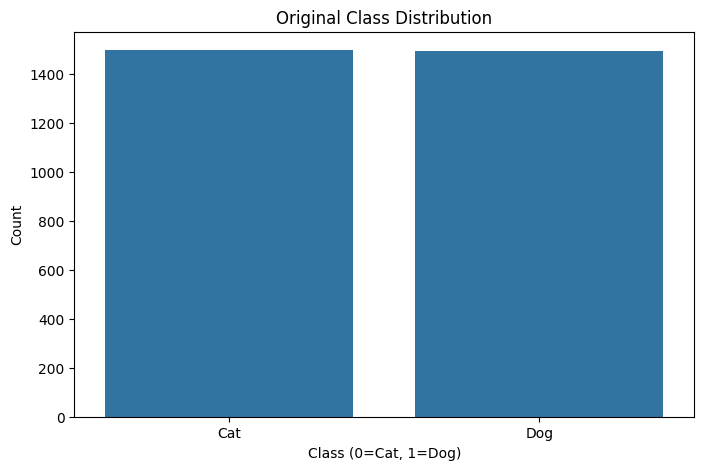

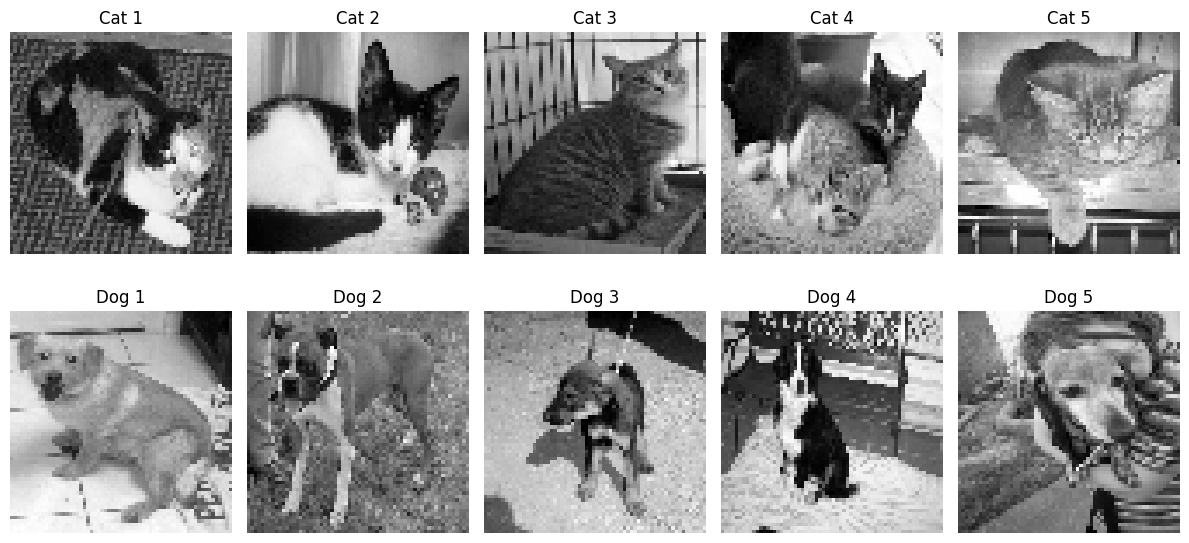

In [4]:
# Visualize original class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x=y)
plt.title('Original Class Distribution')
plt.xlabel('Class (0=Cat, 1=Dog)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Cat', 'Dog'])
plt.show()

# Display a few sample images
plt.figure(figsize=(12, 6))
for i in range(5):
    # Cat samples (class 0)
    cat_indices = np.where(y == 0)[0]
    plt.subplot(2, 5, i+1)
    cat_img = X[cat_indices[i]].reshape(img_size, img_size)
    plt.imshow(cat_img, cmap='gray')
    plt.title(f'Cat {i+1}')
    plt.axis('off')
    
    # Dog samples (class 1)
    dog_indices = np.where(y == 1)[0]
    plt.subplot(2, 5, i+6)
    dog_img = X[dog_indices[i]].reshape(img_size, img_size)
    plt.imshow(dog_img, cmap='gray')
    plt.title(f'Dog {i+1}')
    plt.axis('off')
plt.tight_layout()
plt.show()

# Dimensionality reduction [Feature Selection] / Image augmentation


Performing feature selection...
Reduced features from 4096 to 2000

Performing data augmentation...
Augmented data shape: (5986, 2000)
Augmented class distribution: [2996 2990]


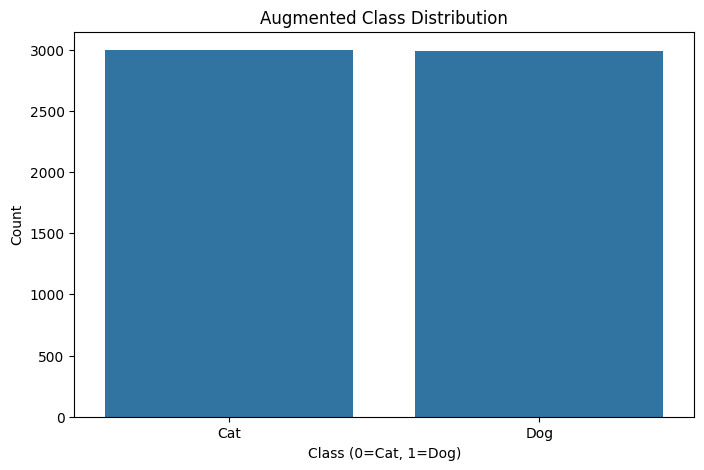

In [5]:
# Feature selection to reduce dimensionality
print("\nPerforming feature selection...")
selector = SelectKBest(f_classif, k=2000)  # Select top 2000 features (~48% of 64*64)
X_selected = selector.fit_transform(X, y)
print(f"Reduced features from {X.shape[1]} to {X_selected.shape[1]}")


# Simple data augmentation to reduce overfitting
print("\nPerforming data augmentation...")
X_aug = list(X_selected)  # Start with original data
y_aug = list(y)

# Add slightly perturbed versions of samples (simple augmentation)
for i in range(len(X_selected)):
    # Add noise to create a new sample
    perturbed = X_selected[i] + np.random.normal(0, 0.05, X_selected[i].shape)
    X_aug.append(perturbed)
    y_aug.append(y[i])

X_aug = np.array(X_aug)
y_aug = np.array(y_aug)

print(f"Augmented data shape: {X_aug.shape}")
print(f"Augmented class distribution: {np.bincount(y_aug)}")

# Visualize augmented class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x=y_aug)
plt.title('Augmented Class Distribution')
plt.xlabel('Class (0=Cat, 1=Dog)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Cat', 'Dog'])
plt.show()

In [6]:
# Split data into training and test sets with stratification to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X_aug, y_aug, test_size=0.25, random_state=42, stratify=y_aug
)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Training set: (4489, 2000), Test set: (1497, 2000)


# Train models

In [7]:
# Train and evaluate models
results = []
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100,  # Number of trees in the forest
        max_depth=10,      # Maximum depth of trees
        min_samples_split=20,  # Minimum samples required to split an internal node
        random_state=42,
        n_jobs=-1  # Use all available processors
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=5,     # Number of neighbors to use
        weights='distance', # Weight points by the inverse of their distance
        n_jobs=-1
    ),
    "SVM": SVC(
        kernel='rbf',      # Radial basis function kernel
        C=1.0,             # Regularization parameter
        probability=True,  # Enable probability estimates
        random_state=42
    ),
    "Logistic Regression": LogisticRegression(
        C=1.0,             # Regularization strength
        max_iter=200,      # Increase iterations for convergence
        random_state=42,
        n_jobs=-1
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,       # Limit depth to prevent overfitting
        min_samples_split=15,
        random_state=42
    ),
    "Naive Bayes": GaussianNB()  # Simple Naive Bayes classifier
}



Training Random Forest...
Random Forest - Accuracy: 0.7622
Training time: 1.58s, Inference time: 0.04s
Confusion matrix:
[[527 222]
 [134 614]]
              precision    recall  f1-score   support

           0       0.80      0.70      0.75       749
           1       0.73      0.82      0.78       748

    accuracy                           0.76      1497
   macro avg       0.77      0.76      0.76      1497
weighted avg       0.77      0.76      0.76      1497

Training accuracy: 0.9501


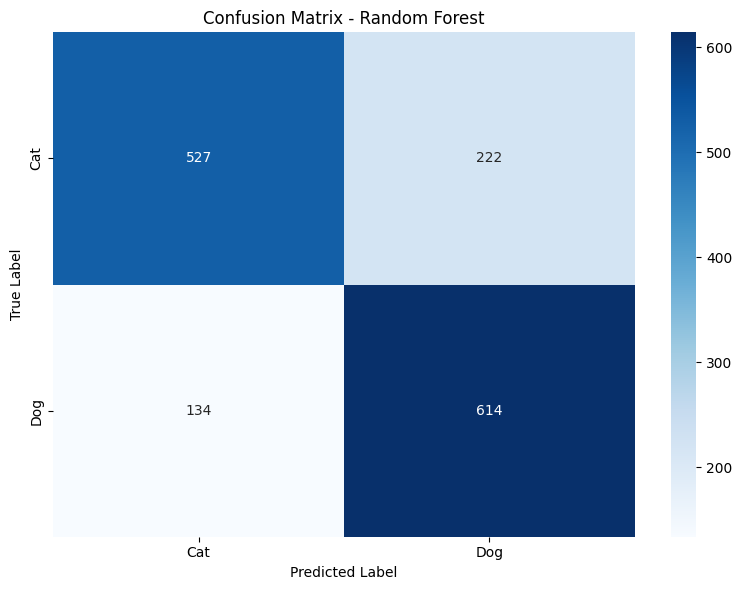


Training KNN...
KNN - Accuracy: 0.8597
Training time: 0.01s, Inference time: 0.31s
Confusion matrix:
[[651  98]
 [112 636]]
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       749
           1       0.87      0.85      0.86       748

    accuracy                           0.86      1497
   macro avg       0.86      0.86      0.86      1497
weighted avg       0.86      0.86      0.86      1497

Training accuracy: 1.0000


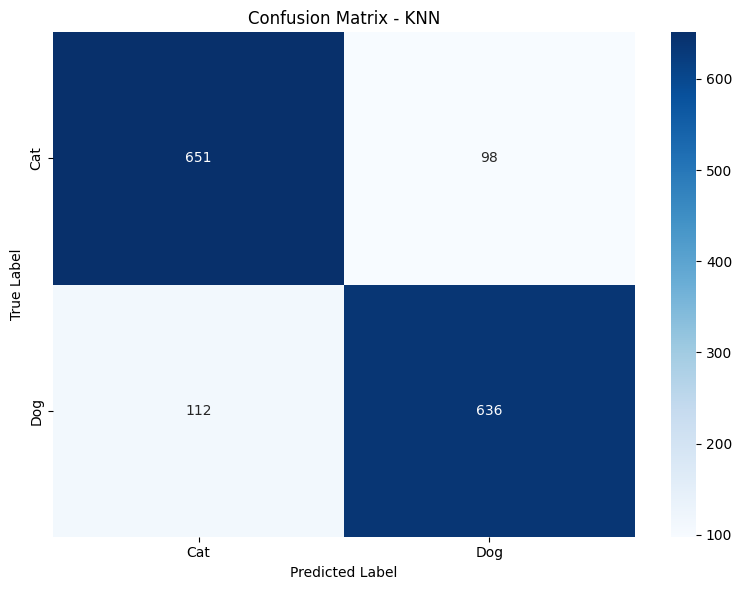


Training SVM...
SVM - Accuracy: 0.7876
Training time: 110.80s, Inference time: 7.30s
Confusion matrix:
[[565 184]
 [134 614]]
              precision    recall  f1-score   support

           0       0.81      0.75      0.78       749
           1       0.77      0.82      0.79       748

    accuracy                           0.79      1497
   macro avg       0.79      0.79      0.79      1497
weighted avg       0.79      0.79      0.79      1497

Training accuracy: 0.9260


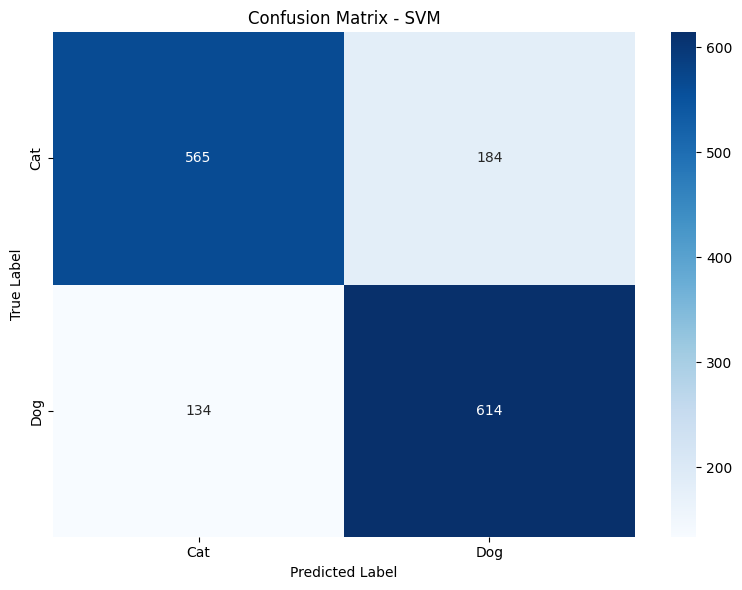


Training Logistic Regression...
Logistic Regression - Accuracy: 0.6339
Training time: 4.09s, Inference time: 0.00s
Confusion matrix:
[[479 270]
 [278 470]]
              precision    recall  f1-score   support

           0       0.63      0.64      0.64       749
           1       0.64      0.63      0.63       748

    accuracy                           0.63      1497
   macro avg       0.63      0.63      0.63      1497
weighted avg       0.63      0.63      0.63      1497

Training accuracy: 0.8806


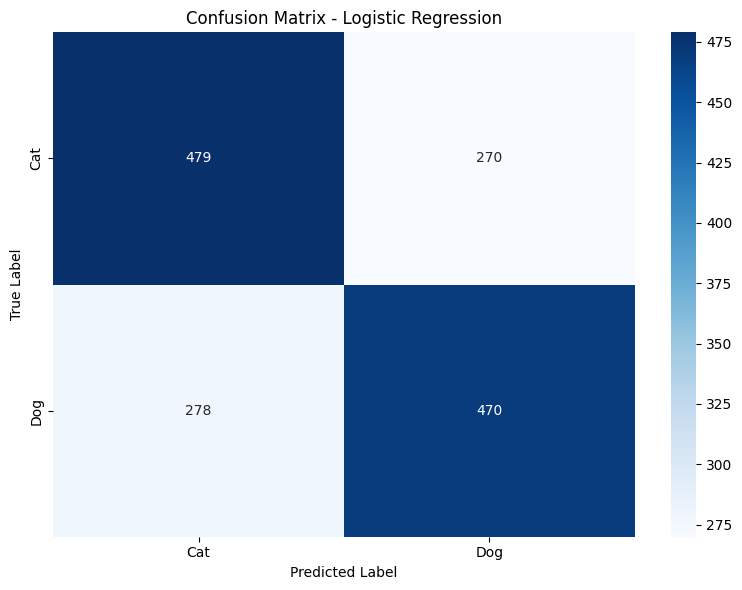


Training Decision Tree...
Decision Tree - Accuracy: 0.6279
Training time: 5.74s, Inference time: 0.01s
Confusion matrix:
[[393 356]
 [201 547]]
              precision    recall  f1-score   support

           0       0.66      0.52      0.59       749
           1       0.61      0.73      0.66       748

    accuracy                           0.63      1497
   macro avg       0.63      0.63      0.62      1497
weighted avg       0.63      0.63      0.62      1497

Training accuracy: 0.7812


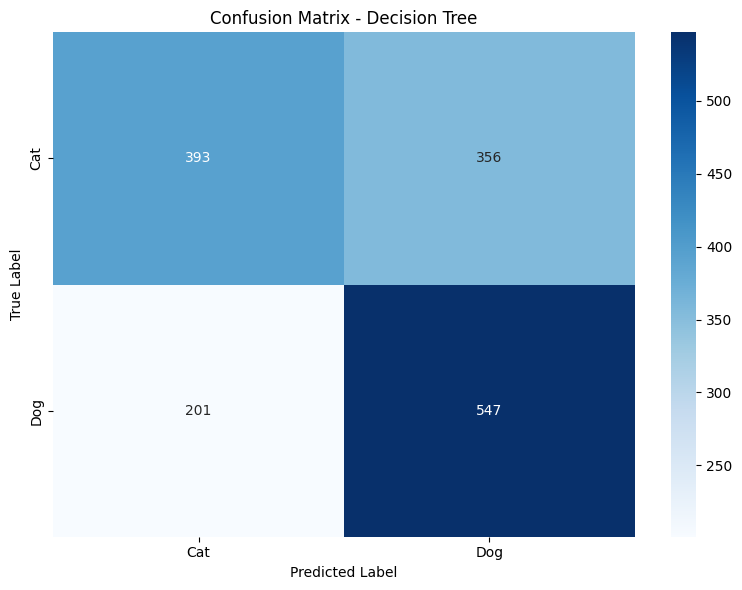


Training Naive Bayes...
Naive Bayes - Accuracy: 0.5898
Training time: 0.14s, Inference time: 0.06s
Confusion matrix:
[[389 360]
 [254 494]]
              precision    recall  f1-score   support

           0       0.60      0.52      0.56       749
           1       0.58      0.66      0.62       748

    accuracy                           0.59      1497
   macro avg       0.59      0.59      0.59      1497
weighted avg       0.59      0.59      0.59      1497

Training accuracy: 0.5750


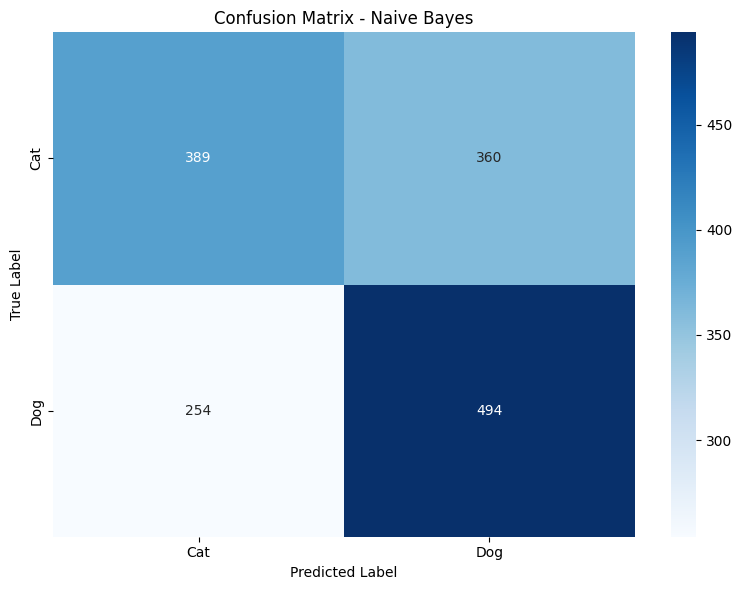

In [8]:
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    
    # Train the model
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # Make predictions
    start_time = time.time()
    y_pred = model.predict(X_test)
    inference_time = time.time() - start_time
    
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"{model_name} - Accuracy: {accuracy:.4f}")
    print(f"Training time: {train_time:.2f}s, Inference time: {inference_time:.2f}s")
    print(f"Confusion matrix:\n{cm}")
    print(classification_report(y_test, y_pred))
    
    # Check for overfitting
    train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, train_pred)
    print(f"Training accuracy: {train_acc:.4f}")
    
    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Training Accuracy': train_acc,
        'Confusion Matrix': cm,
        'Model Object': model
    })

    # Visualize confusion matrix with seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Cat', 'Dog'], 
                yticklabels=['Cat', 'Dog'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()


# visualize metrics

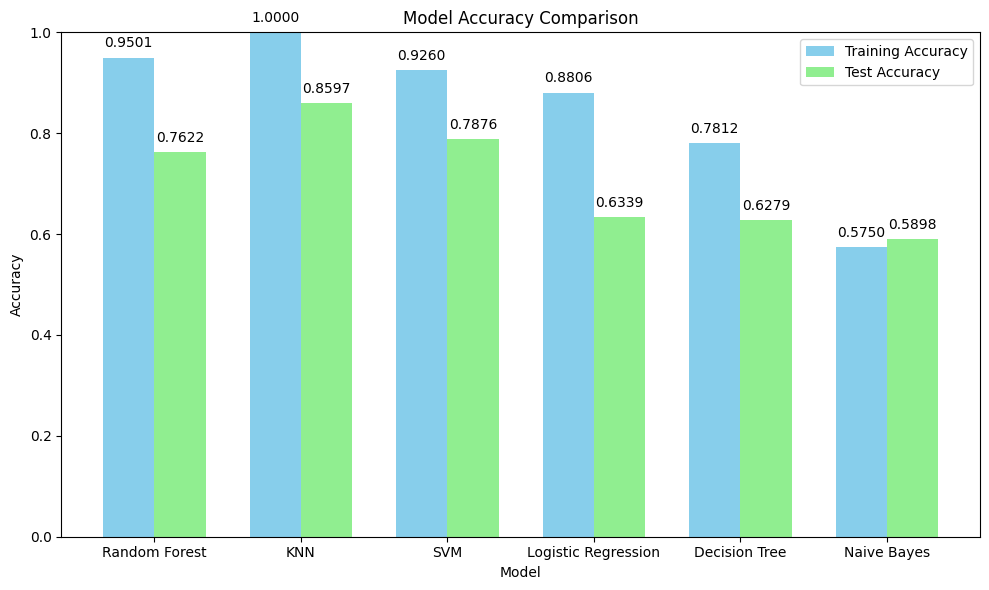

In [9]:
# Visualize accuracy and training accuracy (to detect overfitting)
plt.figure(figsize=(10, 6))
model_names = [r['Model'] for r in results]
accuracies = [r['Accuracy'] for r in results]
train_accuracies = [r['Training Accuracy'] for r in results]

x = np.arange(len(model_names))
width = 0.35

plt.bar(x - width/2, train_accuracies, width, label='Training Accuracy', color='skyblue')
plt.bar(x + width/2, accuracies, width, label='Test Accuracy', color='lightgreen')

plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim([0, 1.0])
plt.xticks(x, model_names)
plt.legend()

# Add text labels
for i, acc in enumerate(accuracies):
    plt.text(i + width/2, acc + 0.02, f'{acc:.4f}', ha='center')
for i, acc in enumerate(train_accuracies):
    plt.text(i - width/2, acc + 0.02, f'{acc:.4f}', ha='center')

plt.tight_layout()
plt.show()

In [10]:
# Find the best model
best_idx = np.argmax([r['Accuracy'] for r in results])
best_model = results[best_idx]
print(f"\nBest model: {best_model['Model']} with accuracy {best_model['Accuracy']:.4f}")


Best model: KNN with accuracy 0.8597


# Image predictor  

Using the best model: KNN
The image is predicted to be a: Cat (Confidence: 80.7%)


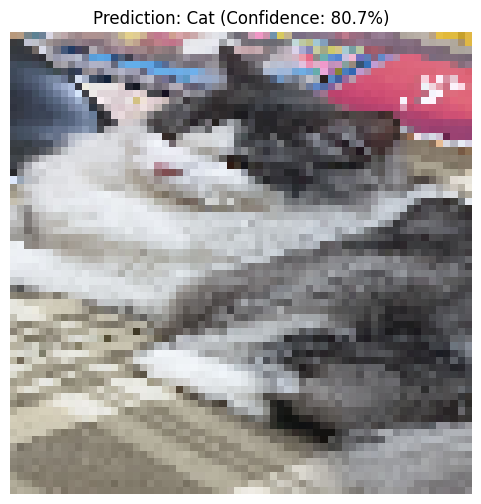

In [12]:
# Find the best model from your results
best_idx = np.argmax([r['Accuracy'] for r in results])
model = results[best_idx]['Model Object']

print(f"Using the best model: {results[best_idx]['Model']}")

user_image_path = r"C:\Users\PC\Desktop\Downloads\CATS\Screenshot_20250507-200337_Gallery.jpg"
    
# Read and preprocess the image
img = cv2.imread(user_image_path)


# Resize and convert to grayscale
img_resized = cv2.resize(img, (img_size, img_size))
gray_img = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

# Transform for prediction
features = gray_img.flatten() / 255.0
features_selected = selector.transform(features.reshape(1, -1))

# Make prediction
prediction = model.predict(features_selected)[0]
class_name = "Dog" if prediction == 1 else "Cat"

# Get probability if available
prob_score = None
if hasattr(model, 'predict_proba'):
    prob_score = model.predict_proba(features_selected)[0][prediction]
    confidence_str = f" (Confidence: {prob_score*100:.1f}%)"
else:
    confidence_str = ""

# Display results
print(f"The image is predicted to be a: {class_name}{confidence_str}")

# Display the image with prediction
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
plt.title(f"Prediction: {class_name}{confidence_str}")
plt.axis('off')
plt.show()